In [8]:
import numpy as np 
import pandas as pd

In [89]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [90]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5171,ham,Oh k. . I will come tomorrow,NaN,NaN,NaN
1461,ham,Kinda. First one gets in at twelve! Aah. Speak...,NaN,NaN,NaN
4322,ham,Aight well keep me informed,NaN,NaN,NaN
1204,spam,WIN a year supply of CDs 4 a store of ur choic...,NaN,NaN,NaN
258,spam,We tried to contact you re your reply to our o...,NaN,NaN,NaN


In [91]:
df.shape

(5572, 5)

### Steps :- 
#### 1. Data Cleaning
#### 2. EDA
#### 3. Text Preprocessing
#### 4. Model Building 
#### 5. Evaluation
#### 6. Improvement
#### 7. Website
#### 8. Deployment

In [12]:
# 1. Data Cleaning

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [95]:
# drop last 3 columns 
df.drop (columns = ['Unnamed: 2', 'Unnamed: 3','Unnamed: 4'], inplace = True)  

In [96]:
df.sample(5)

,v1,v2
2970,ham,Height of Confidence: All the Aeronautics prof...
2439,ham,Rightio. 11.48 it is then. Well arent we all u...
153,ham,As per your request 'Melle Melle (Oru Minnamin...
481,ham,"Yo carlos, a few friends are already asking me..."
4632,ham,Oh wow thats gay. Will firmware update help


In [103]:
# renaming the columns (not descriptive enough)

df.rename(columns = {'v1':'label','v2':'text'}, inplace = True)
df.sample(5)

,label,text
2818,ham,Don't forget who owns you and who's private pr...
510,ham,"8 at the latest, g's still there if you can sc..."
3238,ham,Am okay. Will soon be over. All the best
5394,ham,I dont know exactly could you ask chechi.
2197,ham,Bring it if you got it


In [101]:
# convert the labels into numbers
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [104]:
encoder.fit_transform(df['label'])
# in array 0 is for ham and 1 for spam

array([0, 0, 1, ..., 0, 0, 0])

In [105]:
df['label'] = encoder.fit_transform(df['label'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [106]:
# check missing values
df.isnull().sum()
# no missing values

label    0
text     0
dtype: int64

In [107]:
# check for duplicate values
df.duplicated().sum()

403

In [108]:
# drop the duplicates (there are 403 duplicate values)
df.drop_duplicates( keep ='first')

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [109]:
df = df.drop_duplicates( keep ='first')
df.duplicated().sum()

0

In [110]:
df.shape

(5169, 2)

 #### 2. EDA

In [111]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [112]:
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

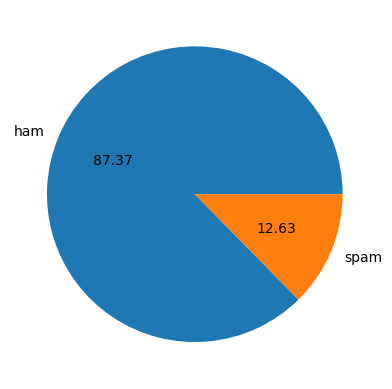

In [113]:
import matplotlib.pyplot as plt
plt.pie(df['label'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f") 
plt.show()

In [40]:
# data is imbalanced 
# in plt.pie the autopct is used for percentage and 02.f means upto two points of decimal
# plt.show is used so that it the pie chart is displayed w/o any other info

In [27]:
import nltk

In [28]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\smrts\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [44]:
# making 3 columns for: characters, words and sentences respectively

In [114]:
# shows no of characters in every sms
df['num_characters'] = df['text'].apply(len)

C:\Users\smrts\AppData\Local\Temp\ipykernel_42560\8257675.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters'] = df['text'].apply(len)


In [115]:
df.head() 

,label,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [116]:
# num of words in every sms(we need to break every word using nltk and lambda function)
df['text'].apply (lambda x: nltk.word_tokenize(x))


0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [117]:
# find no of words (using len function)
df['num_words'] = df['text'].apply (lambda x: len(nltk.word_tokenize(x)))

C:\Users\smrts\AppData\Local\Temp\ipykernel_42560\1157773183.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words'] = df['text'].apply (lambda x: len(nltk.word_tokenize(x)))


In [118]:
df.head()

,label,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [119]:
# find no. of sentences
df['text'].apply (lambda x: nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [120]:
df['num_sentences'] = df['text'].apply (lambda x: len(nltk.word_tokenize(x)))

C:\Users\smrts\AppData\Local\Temp\ipykernel_42560\2535384605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentences'] = df['text'].apply (lambda x: len(nltk.word_tokenize(x)))


In [121]:
df.head()

,label,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,24
1,0,Ok lar... Joking wif u oni...,29,8,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37
3,0,U dun say so early hor... U c already then say...,49,13,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,15


In [122]:
# ham msgs
df[df['label'] == 0]  [['num_characters', 'num_characters', 'num_sentences']].describe()

,num_characters,num_characters,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,70.459256,17.123782
std,56.358207,56.358207,13.493970
min,2.000000,2.000000,1.000000
25%,34.000000,34.000000,8.000000
50%,52.000000,52.000000,13.000000
75%,90.000000,90.000000,22.000000
max,910.000000,910.000000,220.000000


In [123]:
#spam msgs
df[df['label'] == 1 ] [['num_characters', 'num_characters', 'num_sentences']].describe()

,num_characters,num_characters,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,137.891271,27.667688
std,30.137753,30.137753,7.008418
min,13.000000,13.000000,2.000000
25%,132.000000,132.000000,25.000000
50%,149.000000,149.000000,29.000000
75%,157.000000,157.000000,32.000000
max,224.000000,224.000000,46.000000


In [124]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

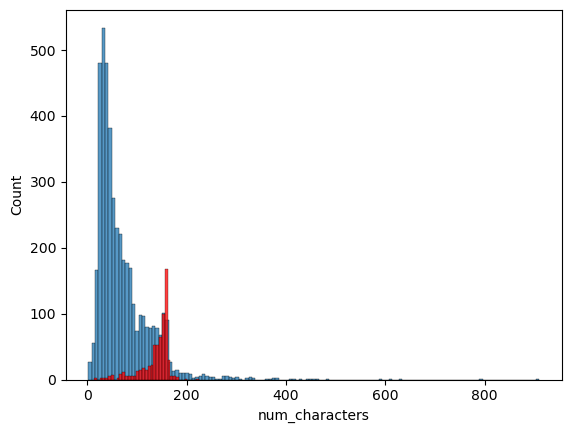

In [125]:
sns.histplot(df[df['label'] == 0 ] ['num_characters'])
sns.histplot(df[df['label'] == 1 ] ['num_characters'], color ='red')

The histogram shows that spam messages generally contain more characters than ham messages, indicating that message length can be a useful feature for distinguishing between spam and legitimate SMS.

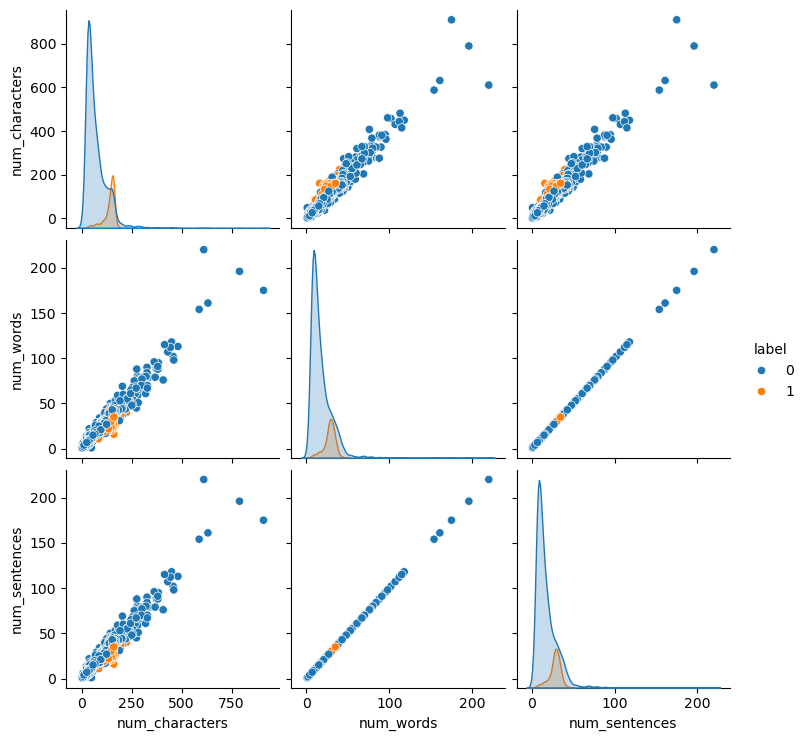

In [126]:
sns.pairplot(df,hue = 'label')

In [69]:
# there are many outliers 

<Axes: >

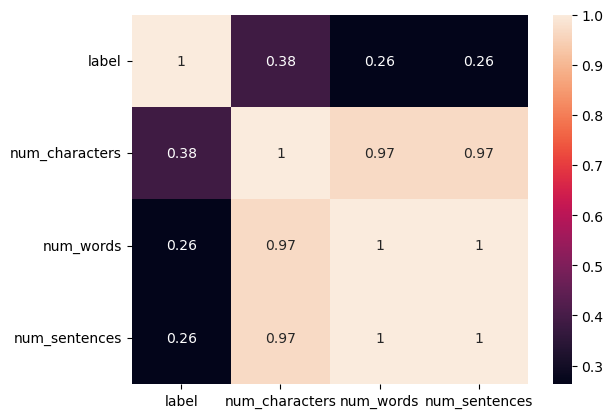

In [127]:
# checking correlations (correlation coefficient)
sns.heatmap(df.corr(numeric_only=True), annot = True)

there is high correlation b/w data ; multicollinearity is present. thus will choose one column and num_characters bcz it has highest variance with label 

In [1]:
# find top or most used words in ham and spam msgs

### 3. Text Preprocessing

- Lowercase
- Tokenization
- Removal of special characters
- Remove stop words and punctuations
- Stemming

In [329]:
import re 
# re handles punctuation

def transform_text(text):
    text = text.lower() 
    # clean but keep numbers + words
    text = re.sub('[^a-zA-Z0-9]', ' ', text) 
    text = text.split()
    # text = nltk.word_tokenize(text)
    
    y = []
    
    stop_words = set(stopwords.words('english'))
    # KEEP important spam words (as 'off' was in stopwords)
    important_words = {'off', 'free', 'win', 'call', 'now', 'buy'}
    
    # remove stopwords
    for i in text:
        if (i not in stop_words) or (i in important_words):
            y.append(ps.stem(i))
      
    return " ".join(y)
    

In [277]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [290]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [260]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [261]:
df ['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [262]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [263]:
df['text'].apply(transform_text)

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u u 750 pound prize 2 c...
5568                                b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: text, Length: 5169, dtype: object

In [330]:
df['transformed_text'] = df['text'].apply(transform_text)

C:\Users\smrts\AppData\Local\Temp\ipykernel_42560\283536690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transformed_text'] = df['text'].apply(transform_text)


In [138]:
df.head()

,label,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,15,nah think goe usf live around though


In [139]:
pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [140]:
from wordcloud import WordCloud
wc = WordCloud(width = 600, height = 600, min_font_size = 10, background_color = 'white')

In [141]:
spam_wc = wc.generate(df[df['label'] == 1 ] ['transformed_text'].str.cat(sep= " "))

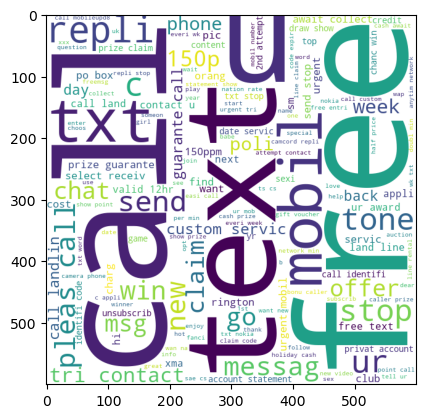

In [142]:
plt.imshow (spam_wc)

In [143]:
ham_wc = wc.generate(df[df['label'] == 1 ] ['transformed_text'].str.cat(sep= " "))

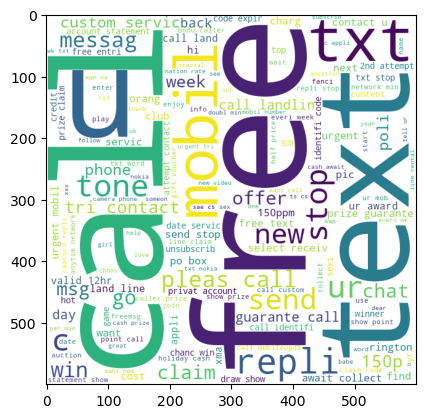

In [144]:
plt.imshow (ham_wc)

In [145]:
spam_corpus = []
for msg in df[df['label'] ==1 ] ['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [146]:
len(spam_corpus)

9939

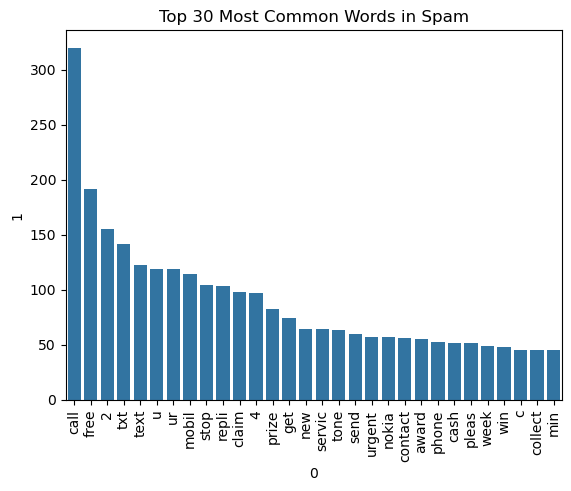

In [149]:
from collections import Counter
spam_df= pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=spam_df[0], y=spam_df[1])
plt.xticks (rotation = 'vertical')
plt.title("Top 30 Most Common Words in Spam")
plt.show()

In [150]:
ham_corpus = []
for msg in df[df['label'] == 0 ] ['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [151]:
len(ham_corpus)

35404

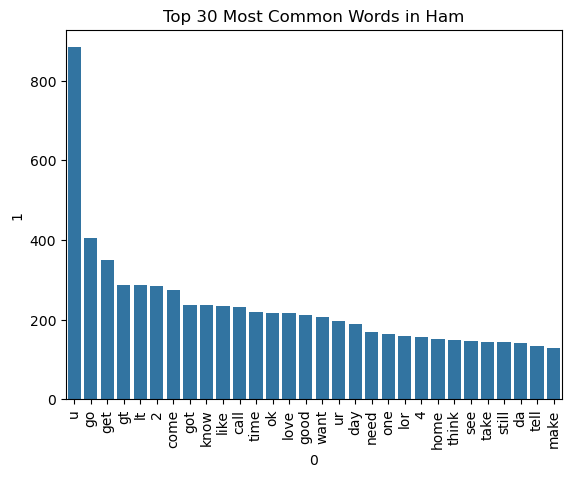

In [152]:
from collections import Counter
ham_df= pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=ham_df[0], y=ham_df[1])
plt.xticks (rotation = 'vertical')
plt.title("Top 30 Most Common Words in Ham")
plt.show()

### 4. Model Building

In [ ]:
#tf-idf
# bow
# word2vec

In [331]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [332]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
Y = df['label'].values

In [333]:
X.shape

(5169, 5000)

In [334]:
Y

array([0, 0, 1, ..., 0, 0, 0])

In [335]:
from sklearn.model_selection import train_test_split
X_train ,X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2, random_state = 2)

In [336]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [337]:
gnb = GaussianNB()
mnb = MultinomialNB(alpha= 0.1)
bnb = BernoulliNB()

In [242]:
gnb.fit(X_train, Y_train)
Y_pred1 = gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))


0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [338]:
mnb.fit(X_train, Y_train)
Y_pred2 = mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))


0.9835589941972921
[[892   4]
 [ 13 125]]
0.9689922480620154


In [244]:
bnb.fit(X_train, Y_train)
Y_pred3 = bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [215]:
## tfidf -> mnb

In [216]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier


In [217]:
svc = SVC(kernel = 'sigmoid', gamma = 1.0 )
dtc = DecisionTreeClassifier (max_depth = 5)
knc = KNeighborsClassifier ()
lrc = LogisticRegression(solver = 'liblinear' , penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [218]:
clfs = {
    'SVC' : svc,
    'KN' : knc ,
    'LR' : lrc,
    'DT' : dtc,
    'xgb' : xgb,
    'ETC' : etc,
    'RF' : rfc,
    'GBDT' : gbdt,
    'BgC' : bc,
    'AdaBoost' : abc
}
    

##### dictionary of name of algo : objects of algo

In [219]:
def train_classifier(clf, X_train,Y_train, X_test, Y_test):
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)

    return accuracy, precision   

In [220]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, Y_train, X_test, Y_test)

    print("For", name)
    print ("Accuracy -", current_accuracy)
    print ("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

For SVC
Accuracy - 0.9758220502901354
Precision - 0.9747899159663865
For KN
Accuracy - 0.9052224371373307
Precision - 1.0
For LR
Accuracy - 0.9584139264990329
Precision - 0.9702970297029703
For DT
Accuracy - 0.9294003868471954
Precision - 0.8282828282828283
For xgb
Accuracy - 0.9671179883945842
Precision - 0.9482758620689655
For ETC
Accuracy - 0.9748549323017408
Precision - 0.9745762711864406
For RF
Accuracy - 0.9758220502901354
Precision - 0.9829059829059829
For GBDT
Accuracy - 0.9468085106382979
Precision - 0.9191919191919192
For BgC
Accuracy - 0.9584139264990329
Precision - 0.8682170542635659
For AdaBoost
Accuracy - 0.9245647969052224
Precision - 0.8488372093023255


In [221]:
performance_df = pd.DataFrame({'Algorithm' : clfs.keys(), 'Accuracy':accuracy_scores, 'Precision': precision_scores}).sort_values('Precision', ascending = False)

### 5. Evaluation

In [222]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
6,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
5,ETC,0.974855,0.974576
2,LR,0.958414,0.970297
4,xgb,0.967118,0.948276
7,GBDT,0.946809,0.919192
8,BgC,0.958414,0.868217
9,AdaBoost,0.924565,0.848837
3,DT,0.929400,0.828283


### 6. Improving Model 

In [223]:
# Voting Classifier
svc = SVC(kernel = 'sigmoid', gamma = 1.0, probability = True )
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)

from sklearn.ensemble import VotingClassifier

In [224]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting = 'soft')

In [225]:
voting.fit(X_train, Y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [226]:
Y_pred = voting.predict(X_test)
print("Accuracy", accuracy_score(Y_test, Y_pred))
print("Precision", precision_score(Y_test, Y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [227]:
#Applying Stacking
estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

from sklearn.ensemble import StackingClassifier

In [228]:
clf = StackingClassifier(estimators = estimators, final_estimator = final_estimator)

In [229]:
clf.fit(X_train,Y_train)
Y_pred = clf.predict(X_test)
print("Accuracy", accuracy_score(Y_test, Y_pred))
print("Precision", precision_score(Y_test, Y_pred))

Accuracy 0.9816247582205029
Precision 0.9541984732824428


### 7. Exporting via Pickle

In [339]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))


### 8. Examples test 

In [328]:
sample = ["Congratulations! You won a free prize. Call now to claim!!!"]
sample_transformed = [transform_text(sample[0])]
sample_vector = tfidf.transform(sample_transformed)

print(mnb.predict(sample_vector))

[1]


In [327]:
print(mnb.predict_proba(sample_vector))

[[0.05010683 0.94989317]]
